In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/Kshitij-1030/human-motion-recognition-IMU.git

from pathlib import Path
ROOT = Path('/content/human-motion-recognition-IMU/external/harth-ml-experiments/adult_walking_speed')
assert ROOT.exists(), f"Path not found: {ROOT}"
files = sorted(ROOT.glob('*.csv'))
print(f"Found {len(files)} CSV files.")
len(files), files[:3]


Mounted at /content/drive
Cloning into 'human-motion-recognition-IMU'...
remote: Enumerating objects: 340, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 340 (delta 0), reused 0 (delta 0), pack-reused 336 (from 3)
Receiving objects: 100% (340/340), 775.34 MiB | 22.33 MiB/s, done.
Resolving deltas: 100% (66/66), done.
Updating files: 100% (166/166), done.
Found 24 CSV files.


(24,
 [PosixPath('/content/human-motion-recognition-IMU/external/harth-ml-experiments/adult_walking_speed/01.csv'),
  PosixPath('/content/human-motion-recognition-IMU/external/harth-ml-experiments/adult_walking_speed/02.csv'),
  PosixPath('/content/human-motion-recognition-IMU/external/harth-ml-experiments/adult_walking_speed/03.csv')])

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, welch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# dictionary of labels
labels = {
    2: "running",
    101: "slow-walking",
    102: "moderate-walking",
    103: "brisk-walking"
}

dfs = []
for f in files:
  df = pd.read_csv(f)
  df["subject_id"] = f.stem
  df["activity"] = df["label"].map(labels)
  dfs.append(df)

df = pd.concat(dfs, ignore_index=True)


In [ ]:
# inspect the dataframe
display(df.head())

# shape of dualsleep df
num_rows = df.shape[0]
num_cols = df.shape[1]
print("Number of rows: ", num_rows)
print("Number of columns: ", num_cols)

# quick summary of df
print("Summary")
display(df.describe(include = 'all'))

# subject counts
print("Subjects: ", df['subject_id'].nunique())

# activity counts
print("Activities: ", df['activity'].value_counts())

# exploring empty values
print("Empty: ", df.isna().sum())

,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject_id,activity
0,2020-11-02 12:12:30.649,-1.000000,-0.125000,-0.264404,-0.968750,-0.093018,-0.107178,101,01,slow-walking
1,2020-11-02 12:12:30.670,-0.999756,-0.123291,-0.265625,-0.968750,-0.093750,-0.121582,101,01,slow-walking
2,2020-11-02 12:12:30.690,-1.001709,-0.107910,-0.265625,-0.966553,-0.093750,-0.127441,101,01,slow-walking
3,2020-11-02 12:12:30.709,-1.017090,-0.109375,-0.265625,-0.981445,-0.093750,-0.110107,101,01,slow-walking
4,2020-11-02 12:12:30.729,-1.015625,-0.109375,-0.265625,-0.984619,-0.093750,-0.121826,101,01,slow-walking


Number of rows:  1780100
Number of columns:  10
Summary


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,label,subject_id,activity
count,1780100,1.780100e+06,1.780100e+06,1.780100e+06,1.780100e+06,1.780100e+06,1.780100e+06,1.780100e+06,1780100,1780100
unique,1780100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,4
top,2021-05-14 13:51:59.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01,moderate-walking
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76435,498960
mean,NaN,-1.002634e+00,-4.731083e-02,-2.683665e-01,-1.045105e+00,-2.112366e-01,-8.795869e-02,8.182999e+01,NaN,NaN
std,NaN,5.293530e-01,2.470666e-01,2.577699e-01,7.390029e-01,5.291088e-01,6.899184e-01,4.010048e+01,NaN,NaN
min,NaN,-8.000000e+00,-3.269531e+00,-3.635986e+00,-8.000000e+00,-8.000000e+00,-7.568848e+00,2.000000e+00,NaN,NaN
25%,NaN,-1.214111e+00,-1.459960e-01,-4.016110e-01,-1.363525e+00,-4.160160e-01,-2.993160e-01,1.010000e+02,NaN,NaN
50%,NaN,-9.790040e-01,-4.296900e-02,-2.409670e-01,-9.724120e-01,-1.809080e-01,-1.953000e-03,1.020000e+02,NaN,NaN
75%,NaN,-8.017580e-01,5.102500e-02,-1.127930e-01,-6.928710e-01,3.881800e-02,2.155760e-01,1.020000e+02,NaN,NaN


Subjects:  24
Activities:  activity
moderate-walking    498960
slow-walking        484800
brisk-walking       437764
running             358576
Name: count, dtype: int64
Empty:  timestamp     0
back_x        0
back_y        0
back_z        0
thigh_x       0
thigh_y       0
thigh_z       0
label         0
subject_id    0
activity      0
dtype: int64


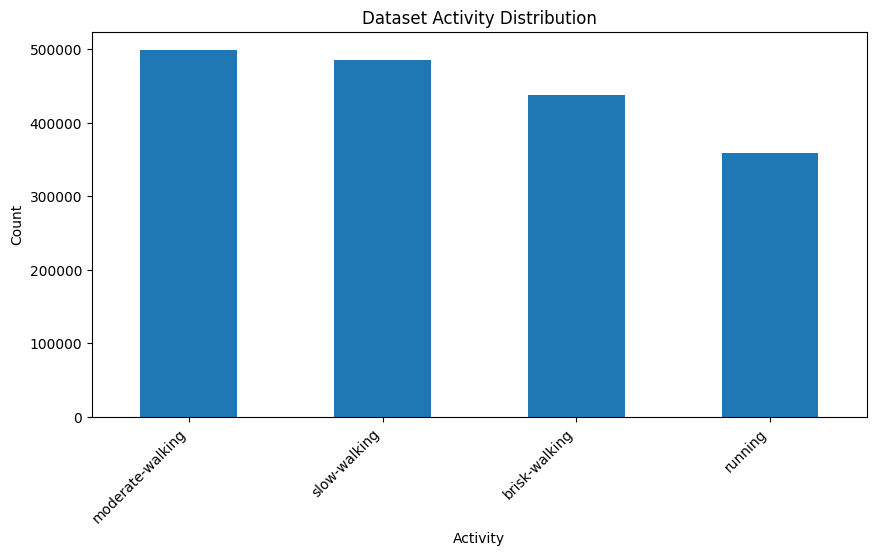

In [ ]:
import matplotlib.pyplot as plt

# visualizing the data
plt.figure(figsize=(10,5))
df['activity'].value_counts().plot(kind='bar')
plt.title("Dataset Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['elapsed_time'] = df.groupby('subject_id')['timestamp'] \
                       .transform(lambda x: (x - x.iloc[0]).dt.total_seconds())

df['window_id'] = (df['elapsed_time'] // 5).astype(int)



In [ ]:
sensor_cols = ['back_x', 'back_y', 'back_z', 'thigh_x', 'thigh_y', 'thigh_z']

# Compute mean, std, min, max for each sensor axis per window
window_features = df.groupby(['subject_id', 'label', 'window_id'])[sensor_cols].agg(['mean', 'std', 'min', 'max'])

window_features.columns = ['_'.join(col).strip() for col in window_features.columns.values]
window_features = window_features.reset_index()


In [ ]:
print(window_features)

     subject_id  label  window_id  back_x_mean  back_x_std  back_x_min  \
0            01      2        271    -1.072408    0.401732   -1.464600   
1            01      2        272    -0.950783    1.080265   -5.460938   
2            01      2        273    -1.024601    1.399256   -7.576904   
3            01      2        274    -1.044652    1.356775   -7.069580   
4            01      2        275    -0.971471    1.119035   -5.445068   
...         ...    ...        ...          ...         ...         ...   
7438         24    103        218    -0.943318    0.369034   -1.776367   
7439         24    103        219    -0.961188    0.328158   -1.601807   
7440         24    103        220    -0.963948    0.346715   -1.664307   
7441         24    103        221    -0.942458    0.345873   -1.646729   
7442         24    103        222    -0.960509    0.289173   -1.684082   

      back_x_max  back_y_mean  back_y_std  back_y_min  ...  thigh_x_min  \
0      -0.225098     0.024129    0.1

In [ ]:
X = window_features.drop(columns=['subject_id', 'label'])
y = window_features['label']

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = window_features['subject_id']
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report



In [ ]:
from sklearn.model_selection import GridSearchCV

# # Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# # Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# # Print the best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best accuracy: 0.8979270194286935


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    min_samples_leaf=1,
    min_samples_split=10,
    max_depth=None

)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.98      0.99      0.98       304
         101       0.98      0.96      0.97       434
         102       0.94      0.87      0.90       426
         103       0.88      0.97      0.93       401

    accuracy                           0.94      1565
   macro avg       0.95      0.95      0.94      1565
weighted avg       0.94      0.94      0.94      1565



In [ ]:
test_meta = window_features.iloc[test_idx][['subject_id', 'window_id']]
test_meta['true_label'] = y_test.values
test_meta['pred_label'] = y_pred

# choose one subject
subject_to_plot = test_meta['subject_id'].unique()[4]
one = test_meta[test_meta['subject_id'] == subject_to_plot]

# sort by window_id
one = one.sort_values('window_id')


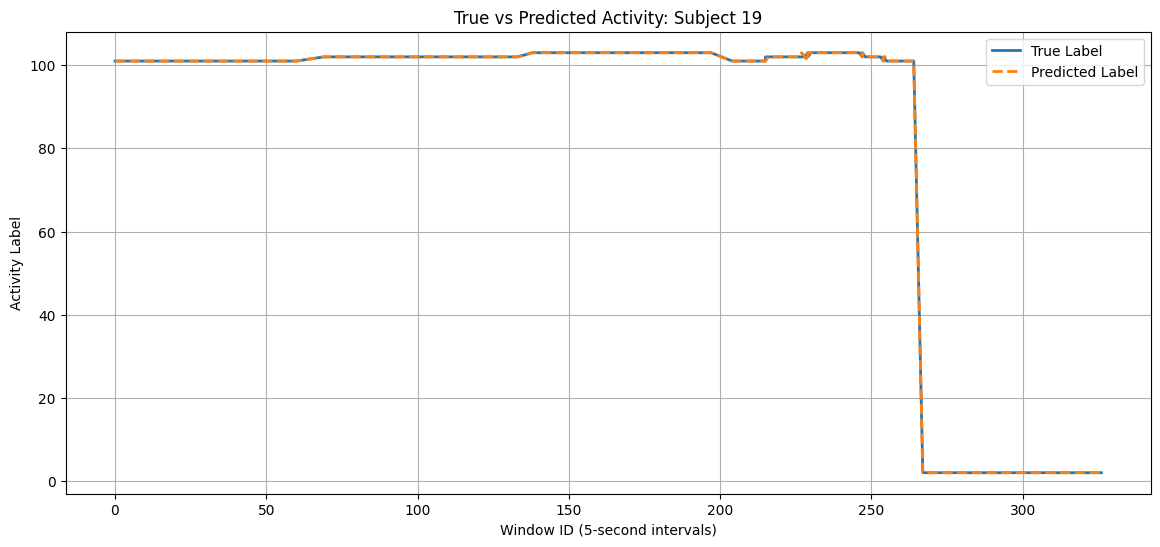

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(one['window_id'], one['true_label'], label="True Label", linewidth=2)
plt.plot(one['window_id'], one['pred_label'], '--', label="Predicted Label", linewidth=2)

plt.xlabel("Window ID (5-second intervals)")
plt.ylabel("Activity Label")
plt.title(f"True vs Predicted Activity: Subject {subject_to_plot}")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
print(X)

      window_id  back_x_mean  back_x_std  back_x_min  back_x_max  back_y_mean  \
0           271    -1.072408    0.401732   -1.464600   -0.225098     0.024129   
1           272    -0.950783    1.080265   -5.460938    0.758789    -0.046136   
2           273    -1.024601    1.399256   -7.576904    1.132324    -0.023545   
3           274    -1.044652    1.356775   -7.069580    1.029053    -0.010911   
4           275    -0.971471    1.119035   -5.445068    0.789551    -0.020823   
...         ...          ...         ...         ...         ...          ...   
7452    3336141    -0.963707    0.345602   -1.776367   -0.297852    -0.141366   
7453    3336142    -0.948905    0.342785   -1.664307   -0.340576    -0.127940   
7454    3336143    -0.962820    0.348594   -1.646729   -0.333740    -0.135246   
7455    3336144    -0.957475    0.306729   -1.684082   -0.370605    -0.122307   
7456    3336145    -0.898486    0.279669   -1.471436   -0.520508    -0.101237   

      back_y_std  back_y_mi